<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula13a_sele%C3%A7%C3%A3o_de_caracter%C3%ADsticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_openml
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
print(X.shape)

(70000, 784)


In [2]:
X_train, X_test, y_train, y_test = X[:60_000], X[60_000:], y[:60_000], y[60_000:]
print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


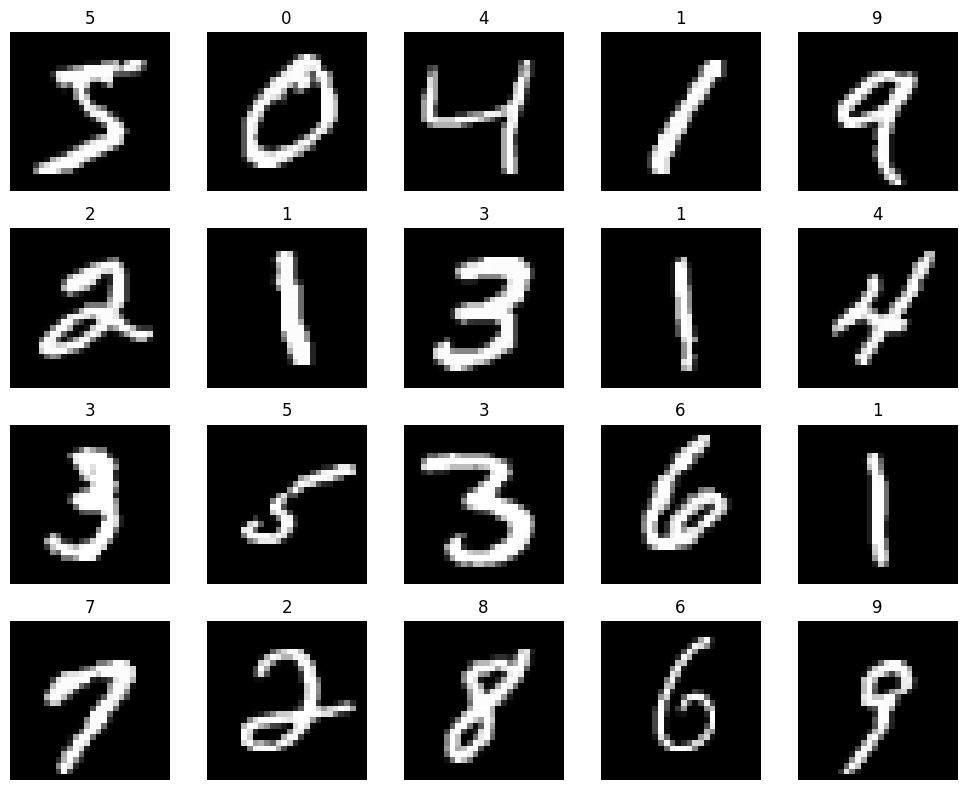

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
for i in range(20):
  plt.subplot(4,5,i+1)
  plt.imshow(X_train[i].reshape(28,28), cmap='gray')
  plt.title(y_train[i])
  plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
sample = X_train[2]
print(sample)

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  67 232
  39   0   0   0   0   0   0   0   0   0  62  81   0   0   0   0   0   0
   0   0   0   0   0   0   0   0 120 180  39   0   0   0   0   0   0   0
   0   0 126 163   0   0   0   0   0   0   0   0   0   0   0   0   0   2
 153 210  40   0   0   0   0   0   0   0   0   0 220 163   0   0   0   0
   0   0   0   0   0   0   0   0   0  27 254 162   

In [5]:
for i in range(784):
  char = '  ' if sample[i] == 0 else ' X'
  print(char, end='')
  if i % 28 == 27:
    print('')

                                                        
                                                        
                                                        
                                                        
                                                        
                                         X X X          
         X X                             X X X          
         X X                           X X X X          
         X X                           X X X            
         X X                           X X X            
       X X X                           X X X            
       X X X                         X X X X            
       X X X                         X X X X            
       X X X                   X X X X X X              
       X X X       X X X X X X X X X X X X              
       X X X X X X X X X X X X X X X X X                
         X X X X X X X X           X X X                
                               

In [6]:
from sklearn.base import BaseEstimator, TransformerMixin

class Normalizer255(BaseEstimator, TransformerMixin):
  def fit(self, X, y=None):
    return self
  def transform(self, X, y=None):
    return X / 255.0

scaler = Normalizer255()
print(scaler.fit_transform(sample))

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         

In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score

pipeline = make_pipeline(Normalizer255(), RidgeClassifier())
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.8604


In [8]:
from sklearn.feature_selection import VarianceThreshold

X_transformed = VarianceThreshold(0.1).fit_transform(X_train)
print(X_transformed.shape)

(60000, 695)


In [9]:
pipeline = make_pipeline(Normalizer255(), VarianceThreshold(0.1), RidgeClassifier())
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.8449


In [10]:
import numpy as np

def pairwise_distances(X, Y=None):
  if Y is None:
    Y = X
  XX = np.sum(X**2, axis=1).reshape(-1,1)
  YY = np.sum(Y**2, axis=1).reshape(1,-1)
  XY = np.dot(X, Y.T)
  distances = np.sqrt(np.maximum(XX - 2*XY + YY, 0))
  return distances

data = np.array([[1,2,3],[2,5,0],[4,8,2],[2,3,6],[5,1,3]])
print(pairwise_distances(data))

[[0.         4.35889894 6.78232998 3.31662479 4.12310563]
 [4.35889894 0.         4.12310563 6.32455532 5.83095189]
 [6.78232998 4.12310563 0.         6.70820393 7.14142843]
 [3.31662479 6.32455532 6.70820393 0.         4.69041576]
 [4.12310563 5.83095189 7.14142843 4.69041576 0.        ]]


In [11]:
for i in range(data.shape[1]):
  print("feature", i)
  dists = pairwise_distances(data[:,i:i+1])
  print(dists)
  print("average", np.mean(dists))
  print()

feature 0
[[0. 1. 3. 1. 4.]
 [1. 0. 2. 0. 3.]
 [3. 2. 0. 2. 1.]
 [1. 0. 2. 0. 3.]
 [4. 3. 1. 3. 0.]]
average 1.6

feature 1
[[0. 3. 6. 1. 1.]
 [3. 0. 3. 2. 4.]
 [6. 3. 0. 5. 7.]
 [1. 2. 5. 0. 2.]
 [1. 4. 7. 2. 0.]]
average 2.72

feature 2
[[0. 3. 1. 3. 0.]
 [3. 0. 2. 6. 3.]
 [1. 2. 0. 4. 1.]
 [3. 6. 4. 0. 3.]
 [0. 3. 1. 3. 0.]]
average 2.08



In [12]:
for i in range(data.shape[1]):
  print(f"features 0:{i}")
  dists = pairwise_distances(data[:,:i+1])
  print(dists)
  print("average", np.mean(dists))
  print()

features 0:0
[[0. 1. 3. 1. 4.]
 [1. 0. 2. 0. 3.]
 [3. 2. 0. 2. 1.]
 [1. 0. 2. 0. 3.]
 [4. 3. 1. 3. 0.]]
average 1.6

features 0:1
[[0.         3.16227766 6.70820393 1.41421356 4.12310563]
 [3.16227766 0.         3.60555128 2.         5.        ]
 [6.70820393 3.60555128 0.         5.38516481 7.07106781]
 [1.41421356 2.         5.38516481 0.         3.60555128]
 [4.12310563 5.         7.07106781 3.60555128 0.        ]]
average 3.366010876046917

features 0:2
[[0.         4.35889894 6.78232998 3.31662479 4.12310563]
 [4.35889894 0.         4.12310563 6.32455532 5.83095189]
 [6.78232998 4.12310563 0.         6.70820393 7.14142843]
 [3.31662479 6.32455532 6.70820393 0.         4.69041576]
 [4.12310563 5.83095189 7.14142843 4.69041576 0.        ]]
average 4.27196962434435



In [13]:
from functools import wraps
import time

def timer(func):
  @wraps(func)
  def wrapper(*args, **kwargs):
    start = time.time()
    result = func(*args, **kwargs)
    end = time.time()
    print(f"{func.__name__} took {end-start} seconds")
    return result
  return wrapper

@timer
def sleep(seconds):
  time.sleep(seconds)

sleep(1)

sleep took 1.0001935958862305 seconds


In [18]:
@timer
def intra_class_mean_distance(X, y):
  mean_dist = 0
  for label in np.unique(y):
    class_data = X[y == label]
    mean_dist += pairwise_distances(class_data, class_data).mean()
  return mean_dist / len(np.unique(y))

print(intra_class_mean_distance(X_train[:,250:251], y_train))

intra_class_mean_distance took 10.161105155944824 seconds
1.0259602140067174


In [44]:
from sklearn.model_selection import train_test_split

X_tr_small, X_val, y_tr_small, y_val = train_test_split(X_train, y_train,
                                                        test_size=0.98,
                                                        stratify=y_train)
print(X_tr_small.shape)
print(X_val.shape)

(1200, 784)
(58800, 784)


In [45]:
print(intra_class_mean_distance(X_tr_small, y_tr_small))

intra_class_mean_distance took 0.14839792251586914 seconds
2286.764757614773


In [46]:
@timer
def inter_class_mean_distance(X, y):
  mean_dist = 0
  for label in np.unique(y):
    in_class = X[y == label]
    out_class = X[y != label]
    mean_dist += pairwise_distances(in_class, out_class).mean()
  return mean_dist / len(np.unique(y))

print(inter_class_mean_distance(X_tr_small, y_tr_small))

inter_class_mean_distance took 1.2472519874572754 seconds
2634.7888153769527


In [47]:
@timer
def distance_score(X, y):
  return intra_class_mean_distance(X, y) / inter_class_mean_distance(X, y)

print(distance_score(X_tr_small, y_tr_small))

intra_class_mean_distance took 0.13811397552490234 seconds
inter_class_mean_distance took 1.280022144317627 seconds
distance_score took 1.418363094329834 seconds
0.8679119724013293


In [48]:
def distance_score(X, y):
  in_dist, out_dist = 0, 0
  for label in np.unique(y):
    in_class = X[y == label]
    out_class = X[y != label]
    in_dist += pairwise_distances(in_class, in_class).mean()
    out_dist += pairwise_distances(in_class, out_class).mean()
  dist_score = in_dist / (out_dist + 1e-8)
  return dist_score if dist_score > 0 else 1e8

start = time.time()
print(distance_score(X_tr_small, y_tr_small))
print(f"took {time.time() - start} seconds")

0.8679119724009998
took 1.5747718811035156 seconds


In [49]:
def univariate_ranking(X, y):
  n_feats = X.shape[1]
  scores = np.empty(n_feats)
  for i in range(n_feats):
    scores[i] = distance_score(X[:,i:i+1], y)
  return scores

start = time.time()
scores = univariate_ranking(X_tr_small, y_tr_small)
print(f"took {time.time() - start} seconds")
print(scores)

took 20.040964126586914 seconds
[1.00000000e+08 1.00000000e+08 1.00000000e+08 1.00000000e+08
 1.00000000e+08 1.00000000e+08 1.00000000e+08 1.00000000e+08
 1.00000000e+08 1.00000000e+08 1.00000000e+08 1.00000000e+08
 1.00000000e+08 1.00000000e+08 1.00000000e+08 1.00000000e+08
 1.00000000e+08 1.00000000e+08 1.00000000e+08 1.00000000e+08
 1.00000000e+08 1.00000000e+08 1.00000000e+08 1.00000000e+08
 1.00000000e+08 1.00000000e+08 1.00000000e+08 1.00000000e+08
 1.00000000e+08 1.00000000e+08 1.00000000e+08 1.00000000e+08
 1.00000000e+08 1.00000000e+08 1.00000000e+08 1.00000000e+08
 9.99735478e-01 9.99735479e-01 9.99157137e-01 9.95674328e-01
 9.99007653e-01 9.96558585e-01 9.99735479e-01 9.99160581e-01
 9.97542212e-01 9.96419557e-01 9.87573985e-01 9.89216378e-01
 9.94252843e-01 1.00000000e+08 1.00000000e+08 1.00000000e+08
 1.00000000e+08 1.00000000e+08 1.00000000e+08 1.00000000e+08
 1.00000000e+08 1.00000000e+08 1.00000000e+08 1.00000000e+08
 1.00000000e+08 1.00000000e+08 1.00000000e+08 9.93934

In [50]:
sorted_idxs = np.argsort(scores)
print(sorted_idxs[:18])

[350 378 542 514 543 515 406 428 409 434 400 461 541 513 377 429 569 433]


In [51]:
print(scores[sorted_idxs[:18]])

[0.62395065 0.62433294 0.64002912 0.65260038 0.65724609 0.65809993
 0.66735423 0.66765377 0.67171108 0.67248129 0.67281976 0.67571697
 0.68354231 0.68429912 0.6875238  0.68830929 0.69057559 0.6953801 ]


In [52]:
class UnivariatedRanking(BaseEstimator, TransformerMixin):
  def __init__(self, n_features):
    self.n_features = n_features
  def fit(self, X, y=None):
    self.scores_ = univariate_ranking(X, y)
    return self
  def transform(self, X, y=None):
    n_features = self.n_features if self.n_features else X.shape[1]
    X_sorted = X[:,self.scores_.argsort()]
    return X_sorted[:,:n_features]

X_selected = UnivariatedRanking(n_features=18).fit_transform(X_tr_small, y_tr_small)
print(X_selected.shape)

(1200, 18)


In [53]:
print(X_selected[0,:])

[166 251 253 253 251 251 251   0 225 253   0 251 251 251 170   0 253 253]


In [54]:
pipeline = make_pipeline(Normalizer255(), RidgeClassifier())
pipeline.fit(X_tr_small, y_tr_small)
y_pred = pipeline.predict(X_val)
print(accuracy_score(y_val, y_pred))

0.7678231292517007


In [55]:
pipeline = make_pipeline(Normalizer255(), UnivariatedRanking(n_features=180), RidgeClassifier())
pipeline.fit(X_tr_small, y_tr_small)
y_pred = pipeline.predict(X_val)
print(accuracy_score(y_val, y_pred))

0.7681292517006802


In [59]:
class HybridRanking(BaseEstimator, TransformerMixin):
  def __init__(self, estimator, random_state=None):
    self.estimator = estimator
    self.random_state = random_state
  def fit(self, X, y=None):
    scores = univariate_ranking(X, y)
    score_idxs = scores.argsort()
    X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2,
                                                stratify=y,
                                                random_state=self.random_state)
    best_score = 0
    best_set = 0
    for i in range(1, len(score_idxs)):
      X_selected = X_tr[:,score_idxs[0:i]]
      self.estimator.fit(X_selected, y_tr)
      acc = self.estimator.score(X_val[:,score_idxs[0:i]], y_val)
      if acc > best_score:
        best_score = acc
        best_set = i
    self.selected_features_ = score_idxs[0:best_set]
    return self
  def transform(self, X, y=None):
    return X[:, self.selected_features_]

pipeline = make_pipeline(Normalizer255(), HybridRanking(RidgeClassifier(), 42), RidgeClassifier())
pipeline.fit(X_tr_small, y_tr_small)
y_pred = pipeline.predict(X_val)
print(accuracy_score(y_val, y_pred))

0.7702551020408164


In [60]:
selector = make_pipeline(Normalizer255(), HybridRanking(RidgeClassifier(), 42))
X_selected = selector.fit_transform(X_tr_small, y_tr_small)
print(X_selected.shape)

(1200, 199)


In [61]:
pipeline = make_pipeline(Normalizer255(), UnivariatedRanking(n_features=199), RidgeClassifier())
pipeline.fit(X_tr_small, y_tr_small)
y_pred = pipeline.predict(X_val)
print(accuracy_score(y_val, y_pred))

0.7702551020408164
